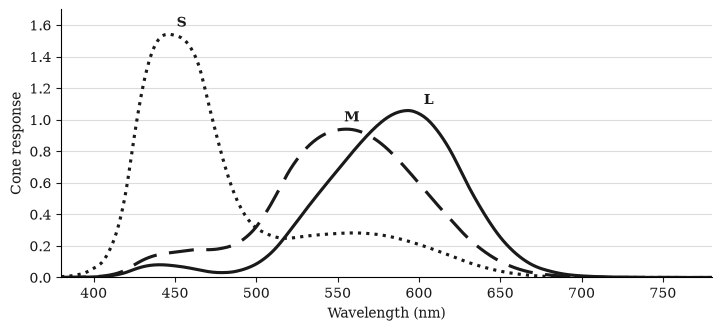

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

import brushcue


ctx = brushcue.Context()

START_WAVELENGTH_NM = 380
END_WAVELENGTH_NM = 780

ASSET_PATH = (
    Path(brushcue.__file__).resolve().parents[3]
    / "writing/graphics/chapters/color-formats/assets/lms/lms-cone-response.svg"
)
ASSET_PATH.parent.mkdir(parents=True, exist_ok=True)

wavelengths = list(range(START_WAVELENGTH_NM, END_WAVELENGTH_NM + 1))
l_values = []
m_values = []
s_values = []

for wavelength_nm in wavelengths:
    color = brushcue.ProfiledColor.from_wavelength_nm(float(wavelength_nm))
    l_value, m_value, s_value, _ = color.to_lmsa().execute(ctx)
    l_values.append(l_value)
    m_values.append(m_value)
    s_values.append(s_value)


plt.rcParams.update({"font.family": "serif", "font.size": 10})

background_color = "#ffffff"
text_color = "#1a1a1a"
line_color = "#1a1a1a"
fig, ax = plt.subplots(
    figsize=(7.1, 3.2), layout="constrained", facecolor=background_color
)
ax.set_facecolor(background_color)
ax.plot(wavelengths, l_values, color=line_color, linewidth=2.25, linestyle="-")
ax.plot(wavelengths, m_values, color=line_color, linewidth=2.25, linestyle=(0, (8, 4)))
ax.plot(wavelengths, s_values, color=line_color, linewidth=2.25, linestyle=":")

ax.set_xlabel("Wavelength (nm)", color=text_color)
ax.set_ylabel("Cone response", color=text_color)
ax.set_xlim(START_WAVELENGTH_NM, END_WAVELENGTH_NM)
ax.set_ylim(0, 1.7)
ax.set_xticks(range(400, 781, 50))
ax.tick_params(colors=text_color)
ax.grid(axis="y", color=line_color, linewidth=0.8, alpha=0.15)
ax.spines[["top", "right"]].set_visible(False)
ax.text(603, 1.10, "L", color=line_color, weight="bold")
ax.text(554, 0.99, "M", color=line_color, weight="bold")
ax.text(451, 1.59, "S", color=line_color, weight="bold")

fig.savefig(ASSET_PATH, format="svg")
ASSET_PATH.write_text("\n".join(line.rstrip() for line in ASSET_PATH.read_text().splitlines()) + "\n")

plt.show()
